## Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

# files = [
#     r"C:\Users\HP\Desktop\Thursday-WorkingHours.csv",
#     r"C:\Users\HP\Desktop\Tuesday-WorkingHours.csv",
#     r"C:\Users\HP\Desktop\Monday-WorkingHours.csv",
#     r"C:\Users\HP\Desktop\Friday-WorkingHours.csv",
#     r"C:\Users\HP\Desktop\Wednesday-WorkingHours.csv"

# ]

# dfs = [pd.read_csv(f) for f in files]
# combined = pd.concat(dfs, ignore_index=True)
# combined.to_csv(r"D:\merged.csv", index=False)



## sample rom the actual data (from 2 m records to 300k )

In [ ]:
data=pd.read_csv("/content/sample_300k .csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 84 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Flow ID                     300000 non-null  object 
 1   Src IP                      300000 non-null  object 
 2   Src Port                    300000 non-null  int64  
 3   Dst IP                      300000 non-null  object 
 4   Dst Port                    300000 non-null  int64  
 5   Protocol                    300000 non-null  int64  
 6   Timestamp                   300000 non-null  object 
 7   Flow Duration               300000 non-null  int64  
 8   Total Fwd Packet            300000 non-null  float64
 9   Total Bwd packets           300000 non-null  float64
 10  Total Length of Fwd Packet  300000 non-null  float64
 11  Total Length of Bwd Packet  300000 non-null  float64
 12  Fwd Packet Length Max       300000 non-null  float64
 13  Fwd Packet Len

In [ ]:
data.isna().sum()

,0
Flow ID,0
Src IP,0
Src Port,0
Dst IP,0
Dst Port,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [ ]:
data.duplicated().sum()

np.int64(28)

In [ ]:
data.shape

(300000, 84)

## attacks

In [ ]:
data.Label.value_counts()

,count
Label,
BENIGN,231232
PortScan,24774
DoS Hulk,24668
DDoS,14807
DoS GoldenEye,1178
DoS slowloris,623
FTP-Patator,618
DoS Slowhttptest - Attempted,524
SSH-Patator,464


## remove highly rare attacks under 50 sample in the data (very misclassified )

In [ ]:

counts = data["Label"].value_counts()

MIN_SAMPLES = 50

valid_classes = counts[counts >= MIN_SAMPLES].index

data = data[data["Label"].isin(valid_classes)].reset_index(drop=True)

print(data["Label"].value_counts())
print("Dropped:", set(counts.index) - set(valid_classes))


Label
BENIGN                                  231232
PortScan                                 24774
DoS Hulk                                 24668
DDoS                                     14807
DoS GoldenEye                             1178
DoS slowloris                              623
FTP-Patator                                618
DoS Slowhttptest - Attempted               524
SSH-Patator                                464
DoS Slowhttptest                           271
DoS slowloris - Attempted                  269
Bot - Attempted                            229
Bot                                        115
DoS Hulk - Attempted                        92
Web Attack - Brute Force - Attempted        68
Name: count, dtype: int64
Dropped: {'Web Attack - XSS - Attempted', 'Web Attack - XSS', 'FTP-Patator - Attempted', 'SSH-Patator - Attempted', 'Heartbleed', 'Infiltration - Attempted', 'Web Attack - Brute Force', 'DoS GoldenEye - Attempted', 'Infiltration', 'Web Attack - Sql Injection'}


## Data Cleaning

In [ ]:
# Check for missing values
print(data.isnull().sum())
data= data.dropna()

Flow ID      0
Src IP       0
Src Port     0
Dst IP       0
Dst Port     0
            ..
Idle Mean    0
Idle Std     0
Idle Max     0
Idle Min     0
Label        0
Length: 84, dtype: int64


In [ ]:
# Remove identifiers not useful for ML
data= data.drop(['Flow ID', 'Src IP', 'Dst IP', 'Timestamp'], axis=1)

In [ ]:
# Replace infinite values
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(0, inplace=True)

## encode the label

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Label'] = le.fit_transform(data['Label'])

# Save label mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))


## check feature correlation

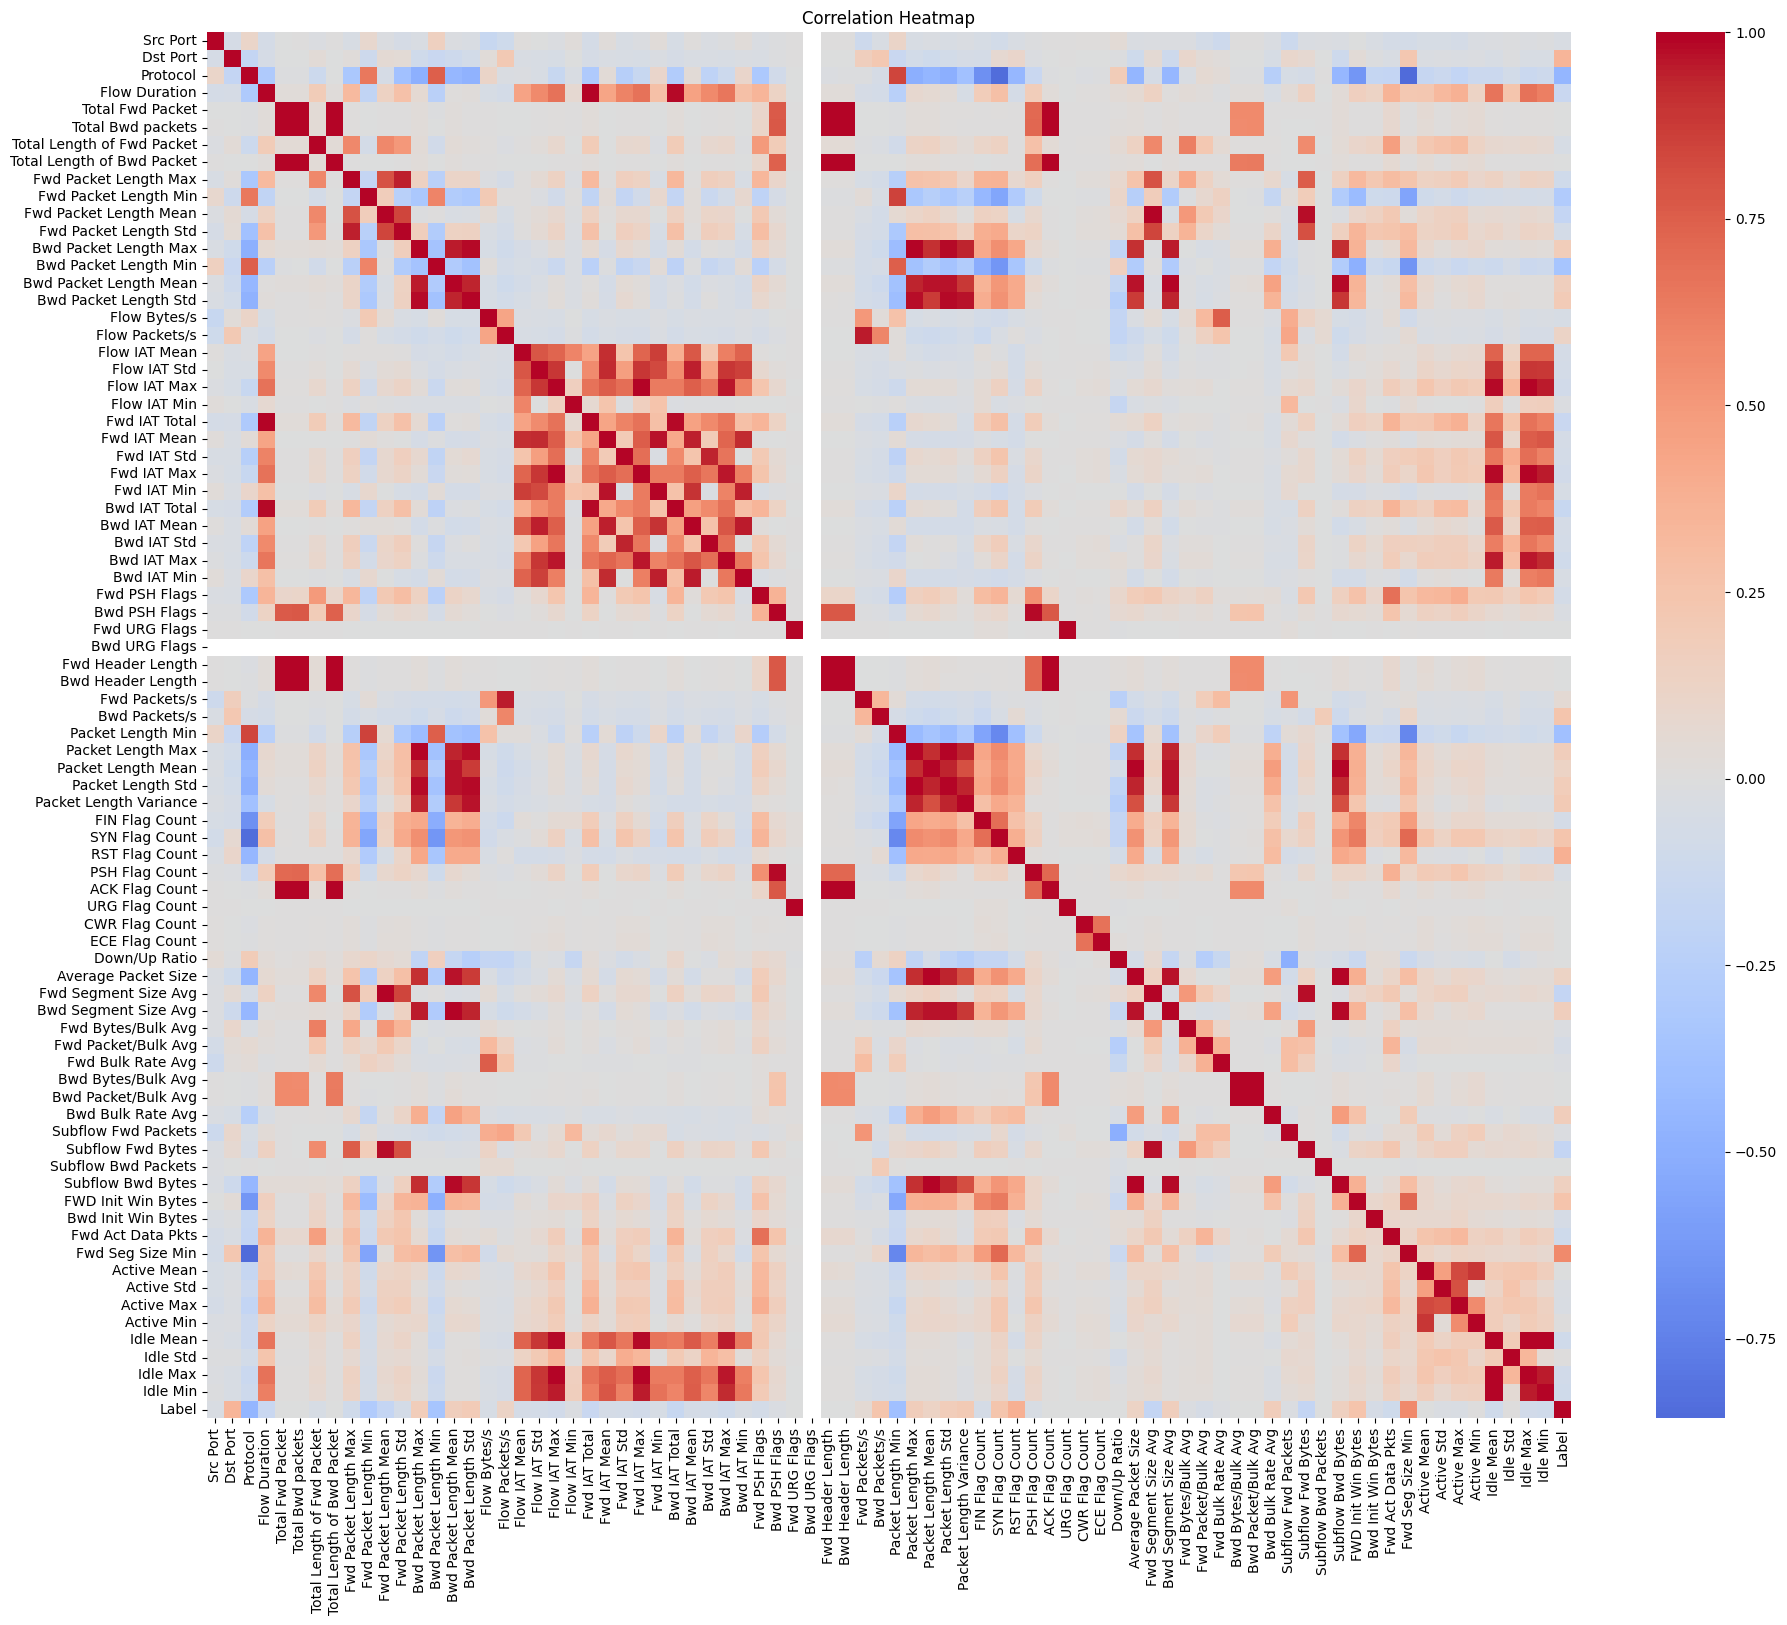

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22, 18))
corr = data.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
corr_with_label = data.corr(numeric_only=True)['Label'].sort_values(ascending=False)
print(corr_with_label)


Label                    1.000000
Fwd Seg Size Min         0.571070
RST Flag Count           0.378237
Dst Port                 0.344040
FWD Init Win Bytes       0.256715
                           ...   
Fwd Packet Length Min   -0.296258
Bwd Packet Length Min   -0.344696
Packet Length Min       -0.384094
Protocol                -0.452601
Bwd URG Flags                 NaN
Name: Label, Length: 80, dtype: float64


In [ ]:
corr_matrix = data.corr(numeric_only=True)

for col in corr_matrix.columns:
    print(f"\n=== Correlations for {col} ===")
    print(corr_matrix[col].sort_values(ascending=False))



=== Correlations for Src Port ===
Src Port                 1.000000
Bwd Packet Length Min    0.153899
Packet Length Min        0.111073
Protocol                 0.101612
Fwd Packet Length Min    0.082929
                           ...   
Fwd Bulk Rate Avg       -0.109868
Fwd Packets/s           -0.111661
Subflow Fwd Packets     -0.123246
Flow Bytes/s            -0.150659
Bwd URG Flags                 NaN
Name: Src Port, Length: 80, dtype: float64

=== Correlations for Dst Port ===
Dst Port                 1.000000
Label                    0.344040
Fwd Seg Size Min         0.228407
Bwd Packets/s            0.221642
Flow Packets/s           0.211983
                           ...   
Subflow Bwd Bytes       -0.114237
Bwd Packet Length Min   -0.143146
Packet Length Min       -0.145396
Protocol                -0.175752
Bwd URG Flags                 NaN
Name: Dst Port, Length: 80, dtype: float64

=== Correlations for Protocol ===
Protocol                 1.000000
Packet Length Min        0.

In [ ]:
X = data.drop('Label', axis=1)
y = data['Label']

## choosing best 30 features based on select kbest algorithm

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

kbest = SelectKBest(score_func=f_classif, k=30)
X_kbest = kbest.fit_transform(X, y)

selected_features_kbest = X.columns[kbest.get_support()]
print("SelectKBest Features:")
print(selected_features_kbest)


SelectKBest Features:
Index(['Dst Port', 'Protocol', 'Fwd Packet Length Min',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Std',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd Packets/s', 'Packet Length Min',
       'Packet Length Max', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
       'RST Flag Count', 'Down/Up Ratio', 'Average Packet Size',
       'Bwd Segment Size Avg', 'Bwd Bulk Rate Avg', 'Subflow Fwd Packets',
       'Subflow Bwd Bytes', 'FWD Init Win Bytes', 'Fwd Seg Size Min',
       'Active Mean', 'Active Min', 'Idle Std'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [35] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
kbest_features = [
    'Dst Port', 'Protocol', 'Fwd Packet Length Min',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Std',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd Packets/s', 'Packet Length Min',
       'Packet Length Max', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
       'RST Flag Count', 'Down/Up Ratio', 'Average Packet Size',
       'Bwd Segment Size Avg', 'Bwd Bulk Rate Avg', 'Subflow Fwd Packets',
       'Subflow Bwd Bytes', 'FWD Init Win Bytes', 'Fwd Seg Size Min',
       'Active Mean', 'Active Min', 'Idle Std'
]


## train test split

In [ ]:
X_selected = data[kbest_features]
y = data['Label']

In [ ]:
for i, cls in enumerate(le.classes_):
    print(i, "→", cls)


0 → BENIGN
1 → Bot
2 → Bot - Attempted
3 → DDoS
4 → DoS GoldenEye
5 → DoS Hulk
6 → DoS Hulk - Attempted
7 → DoS Slowhttptest
8 → DoS Slowhttptest - Attempted
9 → DoS slowloris
10 → DoS slowloris - Attempted
11 → FTP-Patator
12 → PortScan
13 → SSH-Patator
14 → Web Attack - Brute Force - Attempted


## over sampling minority class using smote (highly imbalanced data )

In [ ]:
sampling_strategy = {
    # Large classes (keep original size)
    0: 231232,    # BENIGN
    12: 24774,    # PortScan
    5: 24668,     # DoS Hulk
    3: 14807,     # DDoS

    # Medium classes → oversample moderately
    4: 2000,      # DoS GoldenEye
    9: 2000,      # DoS slowloris
    11: 2000,     # FTP-Patator
    8: 2000,      # DoS Slowhttptest - Attempted
    13: 2000,     # SSH-Patator

    # Medium-small classes
    7: 1000,      # DoS Slowhttptest
    10: 1000,     # DoS slowloris - Attempted

    # Smallest valid classes (≥50)
    2: 1000,       # Bot - Attempted
    1: 1000,       # Bot
    6: 1000,       # DoS Hulk - Attempted
    14: 1000       # Web Attack - Brute Force - Attempted
}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
final_sampling_strategy = {
    cls: n for cls, n in sampling_strategy.items()
    if cls in y_train.unique()
}





## Pipline preprocessing

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline

preprocessing_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(
        sampling_strategy=final_sampling_strategy,
        k_neighbors=1,
        random_state=42
    ))
])


## FIT TRANSFORM AND TRANSFORM TRAIN AND TEST DATA

In [ ]:
X_train_pre, y_train_pre = preprocessing_pipeline.fit_resample(X_train, y_train)

In [ ]:
X_test_scaled = preprocessing_pipeline.named_steps['scaler'].transform(X_test)

| Term                   | Meaning                                                                                                                                                  |
| ---------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Attack**             | A full, active, successful attack producing clear malicious behavior.                                                                                    |
| **Attack – Attempted** | The attacker **tried** to start the attack, but it **did not reach full strength**, was **blocked early**, or **didn't complete the malicious process**. |


| **Label / Name**                              | **Meaning**                     | **Simple Explanation**                                                                                        |
| --------------------------------------------- | ------------------------------- | ------------------------------------------------------------------------------------------------------------- |
| **0 – BENIGN**                                | Normal traffic                  | Regular, safe network activity with no malicious behavior.                                                    |
| **1 – Bot**                                   | Malware-infected device         | A machine controlled remotely by an attacker, used to send spam, perform attacks, or spread malware.          |
| **2 – Bot – Attempted**                       | Attempted bot activity          | Early signs of bot behavior (e.g., scanning, beaconing) but not full control yet.                             |
| **3 – DDoS**                                  | Distributed Denial of Service   | Many infected devices flood a server with massive traffic to make it unavailable.                             |
| **4 – DoS GoldenEye**                         | DoS using GoldenEye tool        | The attacker sends many heavy HTTP requests to overload the web server.                                       |
| **5 – DoS Hulk**                              | Hulk DoS flooding attack        | Floods the server with random, rapidly changing HTTP requests to crash it.                                    |
| **6 – DoS Hulk – Attempted**                  | Attempted Hulk attack           | Partial or incomplete flooding activity that resembles Hulk but is not full-strength.                         |
| **7 – DoS SlowHTTPTest**                      | Slow HTTP DoS attack            | The attacker sends incomplete or slow HTTP requests so the server keeps connections open and gets overloaded. |
| **8 – DoS SlowHTTPTest – Attempted**          | Attempted slow HTTP attack      | Early or partial slow-request behavior without a full attack.                                                 |
| **9 – DoS Slowloris**                         | Slowloris DoS attack            | Sends tiny packets very slowly to exhaust the server’s connection pool.                                       |
| **10 – DoS Slowloris – Attempted**            | Attempted Slowloris             | Slow, incomplete connection attempts that resemble but do not complete a full Slowloris attack.               |
| **11 – FTP-Patator**                          | Brute-force FTP attack          | Many login attempts on an FTP server trying different username/password combos.                               |
| **12 – PortScan**                             | Scanning open ports             | The attacker checks which ports on a machine are open to find potential vulnerabilities.                      |
| **13 – SSH-Patator**                          | Brute-force SSH attack          | Repeated attempts to guess SSH credentials to break into a server.                                            |
| **14 – Web Attack – Brute Force – Attempted** | Attempted web login brute force | Many login tries on a website but not enough traffic yet to classify as a full brute-force attack.            |


## baseline model

## **Logistic** Regression model

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)
model.fit(X_train_pre, y_train_pre)

pred = model.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, pred))



              precision    recall  f1-score   support

           0       1.00      0.99      0.99     46226
           1       0.69      0.96      0.80        23
           2       0.14      0.41      0.21        46
           3       0.99      1.00      1.00      2961
           4       0.94      0.94      0.94       236
           5       1.00      1.00      1.00      4934
           6       0.68      0.94      0.79        18
           7       0.76      0.83      0.80        54
           8       0.89      0.99      0.94       105
           9       0.94      0.71      0.81       125
          10       0.90      0.98      0.94        53
          11       0.97      1.00      0.98       123
          12       0.92      1.00      0.95      4951
          13       0.91      1.00      0.95        93
          14       0.87      1.00      0.93        13

    accuracy                           0.99     59961
   macro avg       0.84      0.92      0.87     59961
weighted avg       0.99   

## Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train_pre, y_train_pre)
pred = rf.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import classification_report

print("\n=== Classification Report ===\n")
print(classification_report(y_test, pred))


=== Classification Report ===

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     46226
           1       1.00      0.96      0.98        23
           2       0.41      0.50      0.45        46
           3       1.00      1.00      1.00      2961
           4       1.00      1.00      1.00       236
           5       1.00      1.00      1.00      4934
           6       1.00      0.94      0.97        18
           7       1.00      0.98      0.99        54
           8       0.99      0.99      0.99       105
           9       1.00      1.00      1.00       125
          10       1.00      1.00      1.00        53
          11       1.00      1.00      1.00       123
          12       0.97      0.97      0.97      4951
          13       1.00      1.00      1.00        93
          14       0.93      1.00      0.96        13

    accuracy                           0.99     59961
   macro avg       0.95      0.96      0.95     

## XGBClassifier(best model for now with 99% overall accuercy with no data leakage )

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='mlogloss')
xgb.fit(X_train_pre, y_train_pre)
pred = xgb.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import classification_report

print("\n=== Classification Report ===\n")
print(classification_report(y_test, pred))



=== Classification Report ===

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     46226
           1       1.00      0.96      0.98        23
           2       0.40      1.00      0.57        46
           3       1.00      1.00      1.00      2961
           4       1.00      1.00      1.00       236
           5       1.00      1.00      1.00      4934
           6       1.00      0.94      0.97        18
           7       1.00      0.96      0.98        54
           8       0.99      0.99      0.99       105
           9       0.99      1.00      1.00       125
          10       1.00      1.00      1.00        53
          11       1.00      1.00      1.00       123
          12       0.97      0.98      0.97      4951
          13       1.00      1.00      1.00        93
          14       0.87      1.00      0.93        13

    accuracy                           0.99     59961
   macro avg       0.95      0.99      0.96     

In [ ]:
import joblib

joblib.dump(xgb, "saved_model.pkl")
joblib.dump(preprocessing_pipeline.named_steps['scaler'], "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model, scaler, and label encoder saved.")


Model, scaler, and label encoder saved.


## data merging

In [ ]:
import pandas as pd
import numpy as np

# Define your 30 KBest features explicitly (must match training exactly)
kbest_features = [
    'Dst Port', 'Protocol', 'Fwd Packet Length Min', 'Bwd Packet Length Max', 
    'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 
    'Fwd IAT Std', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd Packets/s', 
    'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 
    'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 
    'SYN Flag Count', 'RST Flag Count', 'Down/Up Ratio', 'Average Packet Size', 
    'Bwd Segment Size Avg', 'Bwd Bulk Rate Avg', 'Subflow Fwd Packets', 
    'Subflow Bwd Bytes', 'FWD Init Win Bytes', 'Fwd Seg Size Min', 
    'Active Mean', 'Active Min', 'Idle Std'
]

# 1. Load the datasets
live_df = pd.read_csv("/content/17-12-2025.csv") 
original_df = pd.read_csv("/content/sample_300k (1).csv") # Fixed missing )

# 2. Clean column names
live_df.columns = live_df.columns.str.strip()
original_df.columns = original_df.columns.str.strip()

# 3. Handle Labels for Live Data
if 'Label' not in live_df.columns:
    live_df['Label'] = 'BENIGN'

# 4. Filter and Sample Attacks
valid_attacks = [
    'PortScan', 'DoS Hulk', 'DDoS', 'DoS GoldenEye', 'DoS slowloris', 
    'FTP-Patator', 'DoS Slowhttptest - Attempted', 'SSH-Patator', 
    'DoS Slowhttptest', 'DoS slowloris - Attempted', 'Bot - Attempted', 
    'Bot', 'DoS Hulk - Attempted', 'Web Attack - Brute Force - Attempted'
]

attack_pool = original_df[original_df['Label'].isin(valid_attacks)]
# Sample up to 5000, or whatever is available
num_to_sample = min(5000, len(attack_pool))
attack_sample = attack_pool.sample(n=num_to_sample, random_state=42)

# 5. Select ONLY KBest Features + Label
# This ensures both DFs have identical columns before concatenation
cols_to_keep = kbest_features + ['Label']
live_df = live_df[cols_to_keep]
attack_sample = attack_sample[cols_to_keep]

# 6. Merge and Shuffle
merged_df = pd.concat([live_df, attack_sample], axis=0, ignore_index=True)
merged_df = merged_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 7. Final Clean-up
merged_df.replace([np.inf, -np.inf], np.nan, inplace=True)
merged_df.fillna(0, inplace=True)

# 8. Save
merged_df.to_csv("merged_test_data.csv", index=False)

print(f"Merge Complete!")
print(f"Live Benign Rows: {len(live_df)}")
print(f"Injected Attack Rows: {len(attack_sample)}")
print(f"Final Count: {len(merged_df)}")